# Feature extraction

We will be using `FashionClip` to extract visual embedding, and dynamic metadata like style and weather preforming the `Zero-Shot task` using text prompts.

## Refactored Datasets
For our model, we utilize the refactored versions of **The Polyvore Outfits Dataset (2018)**:

[Polyvore]("https://huggingface.co/datasets/owj0421/polyvore"): Contains individual items mapped to their respective labels.

In [29]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import random
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from datasets import load_dataset

### Datasets Loading


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Executing on: {DEVICE.upper()}")

Executing on: CUDA


In [3]:
ds = load_dataset("owj0421/polyvore")

In [4]:
df_polyvore = ds['data'].to_pandas()

In [5]:
df_polyvore.shape

(251008, 6)

In [6]:
df_polyvore.loc[0]

item_id                                                211990161
image          {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
url_name                            neck print chiffon plus size
title                                                           
description                                                     
category                                                    tops
Name: 0, dtype: object

In [7]:
df_polyvore.info()

<class 'pandas.DataFrame'>
RangeIndex: 251008 entries, 0 to 251007
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   item_id      251008 non-null  str   
 1   image        251008 non-null  object
 2   url_name     251008 non-null  str   
 3   title        251008 non-null  str   
 4   description  251008 non-null  str   
 5   category     251008 non-null  str   
dtypes: object(1), str(5)
memory usage: 42.5+ MB


In [8]:
print("Column | empty_count")
print("--------------------")
for column in df_polyvore.columns:
  empty_string_count = (df_polyvore[column] == "").sum()
  print(f"{column} | {empty_string_count}")
  print("")

Column | empty_count
--------------------
item_id | 0

image | 0

url_name | 0

title | 176156

description | 178856

category | 0



In [9]:
df_polyvore = df_polyvore.drop(columns=["title", "description"])

In [10]:
df_polyvore.loc[0: 5]

,item_id,image,url_name,category
0,211990161,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,neck print chiffon plus size,tops
1,183179503,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,christian pellizzari floral jacquard trousers,bottoms
2,152771755,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,natures jewelry stainless steel not,jewellery
3,190445143,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,balmain women high waist flared,bottoms
4,211444470,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,acler orson high waist belted,bottoms
5,192704091,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,christian louboutin girlystrappi bow 100mm,shoes


In [11]:
def clean_image_column(item):
    if isinstance(item, (bytes, bytearray)):
        return item

    if isinstance(item, dict) and "bytes" in item:
        return clean_image_column(item["bytes"])
    return None

In [12]:
df_polyvore['image'] = df_polyvore['image'].apply(clean_image_column)

In [13]:
df_polyvore.iloc[: 5]

,item_id,image,url_name,category
0,211990161,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,neck print chiffon plus size,tops
1,183179503,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,christian pellizzari floral jacquard trousers,bottoms
2,152771755,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,natures jewelry stainless steel not,jewellery
3,190445143,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,balmain women high waist flared,bottoms
4,211444470,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,acler orson high waist belted,bottoms


In [14]:
image_lookup = {}
for index, row in df_polyvore.iterrows():
    image_id = row['item_id']
    if  image_id not in image_lookup.keys(): 
        image_lookup[image_id] = row['image']

### Visualization

Category distribution

In [15]:
image_lookup = {}
for index, row in df_polyvore.iterrows():
    image_id = row['item_id']
    if  image_id not in image_lookup.keys(): 
        image_lookup[image_id] = row['image']

### Feature Extraction

In [16]:
clip_model = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1031.93it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [18]:
STYLES = [
    "casual everyday clothing", "formal business professional attire", 
    "urban streetwear fashion", "bohemian boho free spirit", 
    "sporty athletic activewear", "elegant evening gown", 
    "vintage retro 70s 80s", "minimalist clean simple"
]
STYLE_LABELS = ["Casual", "Formal", "Streetwear", "Bohemian", "Sporty", "Elegant", "Vintage", "Minimalist"]

WEATHER = [
    "summer clothing warm weather", 
    "winter clothing cold weather snow", 
    "transitional spring fall weather"
]
WEATHER_LABELS = ["Summer", "Winter", "Transitional"]

def get_text_embeddings(prompts):
    inputs = clip_processor(text=prompts, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
    with torch.no_grad():
        outputs = clip_model.get_text_features(**inputs)
        
    if not isinstance(outputs, torch.Tensor):
        if hasattr(outputs, 'text_embeds'):
            embeddings = outputs.text_embeds
        elif hasattr(outputs, 'pooler_output'):
            embeddings = outputs.pooler_output
        else:
            embeddings = outputs[0]
    else:
        embeddings = outputs
        
    return F.normalize(embeddings, p=2, dim=-1)

print("Pre-computing text embeddings...")
style_text_features = get_text_embeddings(STYLES)
weather_text_features = get_text_embeddings(WEATHER)
print("Text embeddings ready.")

Pre-computing text embeddings...
Text embeddings ready.


In [26]:
def extract_features_batch(images, temperature=0.05):
    inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
    
    with torch.no_grad():
        img_features = clip_model.get_image_features(**inputs)
        if not isinstance(img_features, torch.Tensor):
            if hasattr(img_features, 'text_embeds'):
                img_features = img_features.text_embeds
            elif hasattr(img_features, 'pooler_output'):
                img_features = img_features.pooler_output
            else:
                img_features = img_features[0]

    img_features_norm = F.normalize(img_features, p=2, dim=-1)
    
    # Similarity = (Image_Vectors @ Text_Vectors.T)
    style_sim = (img_features_norm @ style_text_features.T)
    weather_sim = (img_features_norm @ weather_text_features.T)
    
    # Top indices
    best_styles = torch.argmax(style_sim, dim=-1).cpu().numpy()
    best_weathers = torch.argmax(weather_sim, dim=-1).cpu().numpy()
    
    extracted_styles = [STYLE_LABELS[idx] for idx in best_styles]
    extracted_weathers = [WEATHER_LABELS[idx] for idx in best_weathers]
    
    return img_features.cpu().numpy(), extracted_styles, extracted_weathers

In [27]:
BATCH_SIZE = 64
all_embeddings = []
all_styles = []
all_weathers = []

# Process in batches
for i in tqdm(range(0, len(df_polyvore), BATCH_SIZE), desc="Extracting Polyvore Features"):
    batch = df_polyvore[i : i + BATCH_SIZE]
    images = batch["image"] 
    
    images = [Image.open(io.BytesIO(img)).convert("RGB") for img in images]
    emb, styles, weathers = extract_features_batch(images)
    
    all_embeddings.extend(emb.tolist())
    all_styles.extend(styles)
    all_weathers.extend(weathers)

df_results = pd.DataFrame({
    "image_id": df_polyvore["item_id"], 
    "category": df_polyvore["category"],    
    "style": all_styles,
    "weather": all_weathers,
    "embedding": all_embeddings
})

Extracting Polyvore Features: 100%|██████████| 3922/3922 [14:53<00:00,  4.39it/s]


In [28]:
df_results

,image_id,category,style,weather,embedding
0,211990161,tops,Casual,Transitional,"[-0.08114317804574966, 0.698244571685791, 0.22..."
1,183179503,bottoms,Sporty,Transitional,"[0.2485003024339676, -0.13330161571502686, 0.5..."
2,152771755,jewellery,Bohemian,Transitional,"[-0.47855344414711, 0.40297797322273254, -0.56..."
3,190445143,bottoms,Vintage,Winter,"[0.22234272956848145, -0.4568042457103729, -0...."
4,211444470,bottoms,Formal,Summer,"[-0.17715060710906982, 0.005566656589508057, 0..."
...,...,...,...,...,...
251003,108411005,bottoms,Vintage,Summer,"[-0.38890182971954346, 0.715599536895752, 0.11..."
251004,212452593,outerwear,Sporty,Summer,"[-0.23289616405963898, -0.025017328560352325, ..."
251005,208651882,scarves,Bohemian,Transitional,"[-0.1361992359161377, 0.5828375816345215, -0.4..."
251006,209210426,tops,Bohemian,Summer,"[-0.27166277170181274, 1.1801621913909912, 0.2..."


Validating FashionCLIP Extraction Results...


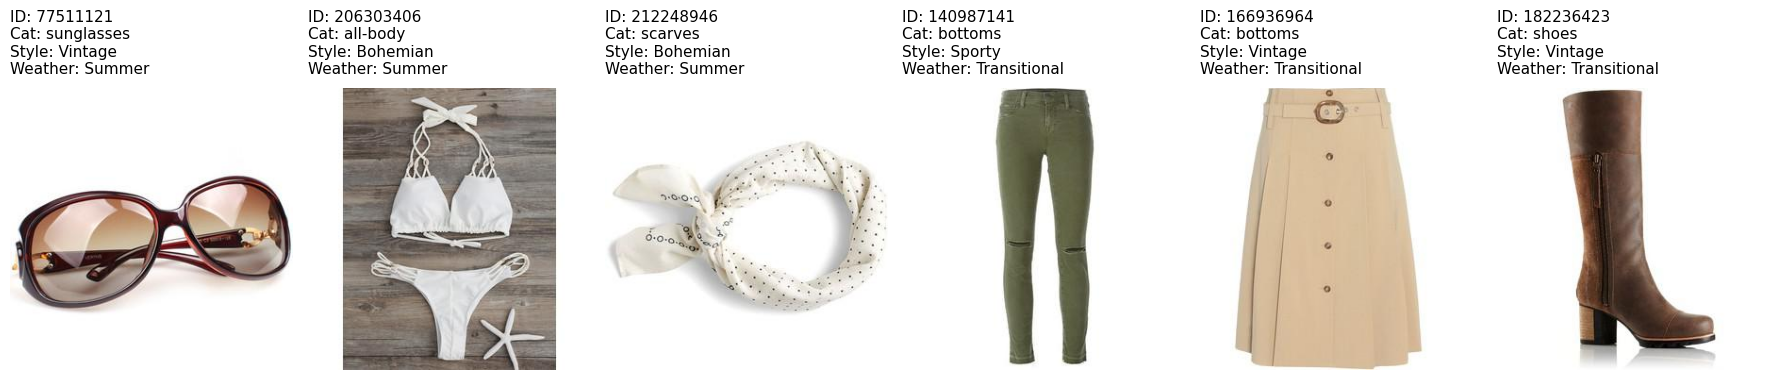

In [31]:
def visualize_extraction_samples(df_source, df_extracted, num_samples=6):
    sample_indices = random.sample(range(len(df_extracted)), num_samples)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(18, 5))
    
    for i, idx in enumerate(sample_indices):
        row = df_extracted.iloc[idx]
        raw_img = df_source.iloc[idx]["image"]
        
        if isinstance(raw_img, dict) and 'bytes' in raw_img and raw_img['bytes'] is not None:
            img = Image.open(io.BytesIO(raw_img['bytes']))
        elif isinstance(raw_img, bytes):
            img = Image.open(io.BytesIO(raw_img))
        elif isinstance(raw_img, Image.Image):
            img = raw_img
        else:
            img = Image.open(raw_img)
            
      
        ax = axes[i]
        ax.imshow(img.convert("RGB"))
        ax.axis('off')
        

        title = (
            f"ID: {row['image_id']}\n"
            f"Cat: {row['category']}\n"
            f"Style: {row['style']}\n"
            f"Weather: {row['weather']}"
        )
 
        ax.set_title(title, fontsize=11, loc='left', pad=10)
        
    plt.tight_layout()
    plt.show()


print("Validating FashionCLIP Extraction Results...")
visualize_extraction_samples(df_polyvore, df_results, num_samples=6)

In [32]:
OUTPUT_PATH = "./polyvore_fashionclip_features.parquet"
df_results.to_parquet(OUTPUT_PATH, engine="pyarrow", index=False)
print(f"Extraction complete! Saved to {OUTPUT_PATH}")

Extraction complete! Saved to ./polyvore_fashionclip_features.parquet
